In [1]:
from nn import Value
from viz import draw_dot

In [3]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e+c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label='L'
L

Value(data=-8.0, children={Value(data=4.0, children={Value(data=-6.0, children={Value(data=2.0, children=set()), Value(data=-3.0, children=set())}), Value(data=10.0, children=set())}), Value(data=-2.0, children=set())})

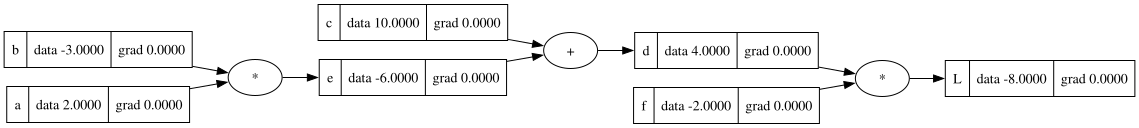

In [3]:
draw_dot(L)

In [4]:
# Value.grad - represents the local derivative w.r.t L


# FILLING IN THE GRADIENT
# what is the derivative is L with respect to L - i.e. if I change L a little bit h, how m
# lets estimate it numerically
def gradient_example_l_wrt_a():
    h  = .0001 # bump L by a tiny amnt
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    
    a = Value(2.0 + h, label='a') # here we nudge a - by h
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data

    print((L2-L1)/h) 

gradient_example_l_wrt_a()

6.000000000021544


In [5]:
def gradient_example_l_wrt_l():
    h  = .0001 # bump L by a tiny amnt
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    
    a = Value(2.0, label='a') 
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h
    print((L2-L1)/h) # here we nudge A

gradient_example_l_wrt_l()
    

0.9999999999976694


In [6]:
# so we can set our first grad as L as the starting node:

In [7]:
L.grad=1.0

In [8]:
# well we know that: 
# L = d * f
# what would dL/dd? -> f
# following suite - f's grad would be
# dL/df -> d which we know equals 4 from our graph
f.grad = 4
# to check we can check how we did the example functions above

In [9]:
# Now how would we find out dL/dc
# f isn't in terms of c so we need the chain rule to find it
# L = d*f
# but d = e + c 
# dL/dC = dL/dd * dd/dc = f * 1 = -2 

In [10]:
# to verify
def gradient_example_l_wrt_c():
    h  = .0001 # bump L by a tiny amnt
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    
    a = Value(2.0, label='a') 
    b = Value(-3.0, label='b')
    c = Value(10.0 +h, label='c')
    e = a*b; e.label='e'
    d = e+c; d.label='d'
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data
    print((L2-L1)/h) # here we nudge A

gradient_example_l_wrt_c()

-1.9999999999953388


In [11]:
#therefore
c.grad = -2.0

In [12]:
# at the end of all of these propogations
a.grad = -3.0
b.grad = 2
e.grad=-2
d.grad = -2.0

In [13]:
#reprinting our graphs

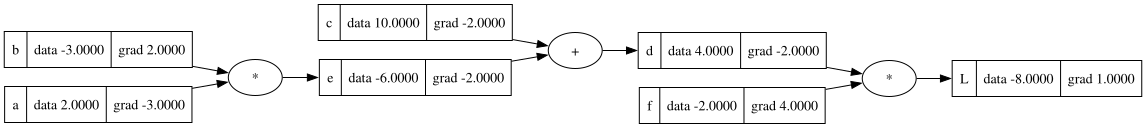

In [14]:
draw_dot(L)

In [6]:
# okay lets do another example but on Neurons
import numpy as np

#inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#biases
b = Value(6.7, label= 'b')

x1w1= x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1w1+x2w2'
n = x1w1+x2w2 + b; n.label='n'

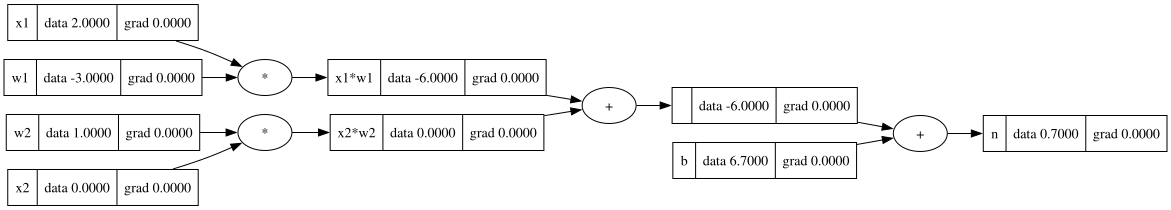

In [7]:
draw_dot(n)

In [8]:
# we are now going to place it through an activation function - a tanh
# the problem is that tanh is defined as = e^{2x} - 1 / e^{2x} +1 
# but our values don't know how neither expoenentiate nor divide
o = n.tanh(); o.label='o'

In [9]:
# and now that we have o we have use this as our output

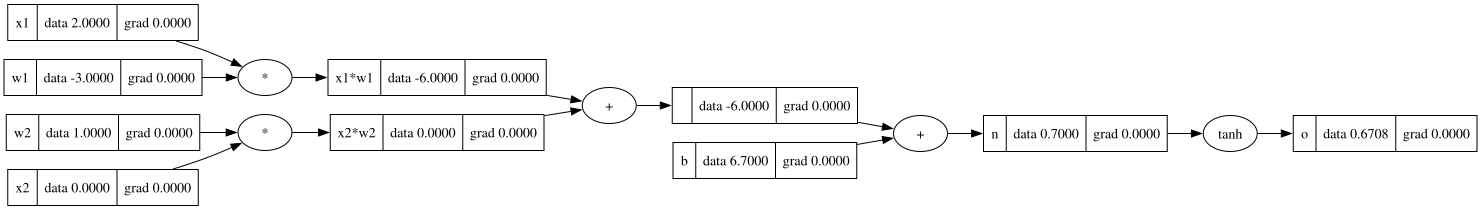

In [10]:
draw_dot(o)

In [20]:
#now we have to backprop through tanh
# if o = tanh(n)
# then do/dn = 1 - tanh(n)**2 = 1 - o**2

In [21]:
# calculating our grads
o.grad =  1
n.grad = .5 # 1 - o.data**2

# n = x1w1+x2w2 +b 
# do/d(x1w1+x2w2) = do/dn dn/d(x1w1+x2w2) = (.5) * (1)
x1w1x2w2.grad = .5
# similarly
b.grad = .5
# continuing on with this we arrive for the previous nodes with 
x1w1.grad = .5; x2w2.grad=.5
# for x2
# do/dx2 = do/dn * dn/d{x1w1+x2w2) * d{x1w1+x2w2}/dx2w2 * dx2w2 / dx2 = [ do/dx2w2 ] * dx2w2/dx2
x2.grad = w2.data * x2w2.grad 
#similarly
x1.grad = w1.data * x1w1.grad
# and for the weights - same except the last partial is dx2w2/dw2
w1.grad = x1.data * x1w1.grad
w2.grad = x2.data * x2w2.grad

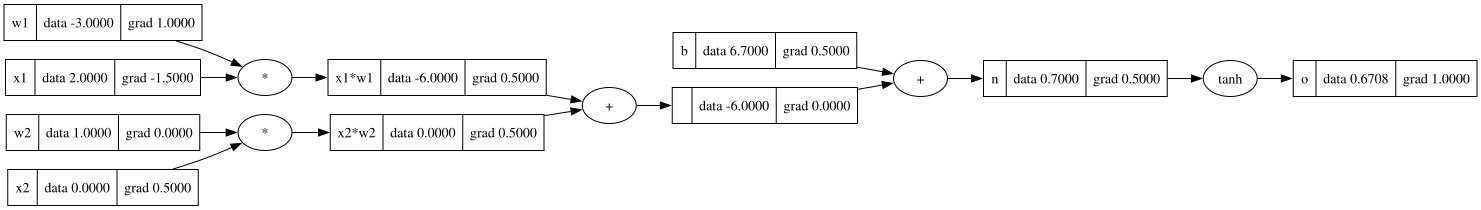

In [22]:
draw_dot(o)
# How does wiggling w2 do to our output?
# the answer is nothing because w1 = x1.data * ... -> which zeroes out our gradient adn therefore our neuron

In [1]:
# Now lets implement backward pass manually - see the Value class implementations of _backwards - these are the generalized rules of what we've been doing
# for example 
# x1w1x2w2 = x1w1 + x2w2 
# do/dx1w1 = (d/dx1w1 [ x1w1 + x2w2)]) * do/dn
# do/dx1w1 = ([1 + 0] * do/dn )
# so for addition its the localgradient that works out to 1 and whatever the other's gradient is 

# for multiplication
# x2*w2 = x2 * w2
# # do/dx2 = do/dn * dn/d{x1w1+x2w2) * d{x1w1+x2w2}/dx2w2 * dx2w2 / dx2 = [ do/dx2w2 ] * dx2w2/dx2
# or the data * the local gradient of the upstream chain

#for activation functions
# its there derivates - in the case we have - its the last neuron but each of the other nodes could also have an activation function 
# so generally its its local gradient* the upstream ones 
# in our case we have 1-(tanh)^2 * upstream gradients

## In order to automate this we set the initial base case - whic we did o.grad = 1
## and then we should be able to call backprop with the following
# o._backward(), etc - but thats a drag - 

In [12]:
# now all thats left is to automate calling backwards on each - the caveat is that before we can call _backwards on a node - 
# we have to make sure that its dependency has to be calculated before we pass over a specfic node - which is solved via a topological sort
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        for child in v._prev:
            build_topo(child)
        topo.append(v)
    return topo

o.grad = 1.0
build_topo(o)

for node in reversed(topo):
    node._backward()

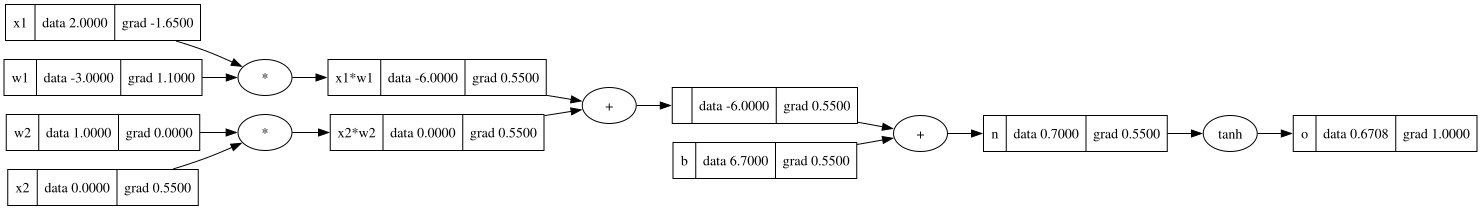

In [13]:
draw_dot(o)

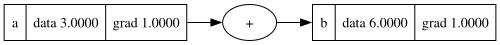

In [4]:
# so now lets actually define backward on the Value object instead - which will do what we did here basically
# now we can just do o.backward() and call it a day
# but were not done yet - take a look at this
a = Value(3.0, label='a')
b = a + a; b.label ='b'
b.backward()
draw_dot(b)

In [2]:
# but thats wrong db/da = 2 not one (b = 2a)
# so why did this occur? its because in this case we are overwriting the grad value because the other node and self node are 
# referrecning the same object - or more generalized - in previous expressions we use each variable at most once 
# in order to fix this - we have to accumulate gradients so all the backwards function go from = to += 

In [4]:
# now that we know how the wheel was invented - lets use a modern framework to recreate what we just did 
import torch
# recall that a tensor is just a array of scalars
x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True # tensor assumes its a leaf node -> we have to explicitly state that it will need
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True # to be able to backprop
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b  = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n  = x1*w1 + x2*w2 + b
o  = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [5]:
# Creating and tuning a neural net
# from our nn module we define a layers and an MLP class that we can use as an abstraction in order to preform everything we've seen
from nn import MLP
n = MLP(3, [4,4,1]) # 3 inputs, follow by two layers of 4 nodes,and one node as output

In [6]:
# so lets make a toy data set
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, .5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
# and we want our desired targets to be
ys = [1.0, -1.0, -1.0, 1.0]
# here we define what our neural net is currently thinking
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.7780652579047267),
 Value(data=-0.5113675328451438),
 Value(data=-0.6823916673519481),
 Value(data=-0.7861593765088253)]

In [7]:
# we define loss as a way to measure how our nn is performing
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.691518120583515)

In [8]:
# we should minimize the loss
loss.backward()
# so now for every param we want to update data slightly according to the gradient information
step_size = .01
for p in n.parameters():
    p.data += -step_size *p.grad

In [9]:
# now we must collect the params of the neural nets
n.parameters()

[Value(data=-0.30111678403647923),
 Value(data=0.4963778063266262),
 Value(data=0.35295061712052545),
 Value(data=0.26032935073449337),
 Value(data=0.07539334467876455),
 Value(data=-0.6354581222840332),
 Value(data=0.9135790535413956),
 Value(data=-0.15306477758590714),
 Value(data=0.9967415367217746),
 Value(data=-0.37134109594595943),
 Value(data=0.3835551822657464),
 Value(data=-0.9675939917656544),
 Value(data=-0.6290901096578929),
 Value(data=0.04891134623680363),
 Value(data=-0.712225681514451),
 Value(data=-0.24623375012029575),
 Value(data=0.4306874975184077),
 Value(data=0.8490740477954487),
 Value(data=-0.016920902480685333),
 Value(data=-0.20050692173335605),
 Value(data=0.04384719328236641),
 Value(data=0.6501609910961699),
 Value(data=0.0014023214622021496),
 Value(data=-0.9520858633977766),
 Value(data=0.7709380024782505),
 Value(data=-0.838637457068993),
 Value(data=-0.7272121762025353),
 Value(data=0.05176694361995231),
 Value(data=-0.40352470993412554),
 Value(data=0.

In [35]:
# re- evaluate the predictions
ypred_new = [n(x) for x in xs]

In [37]:
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred_new))
loss
# as you can see the loss is slightly reduced

Value(data=4.397600268532061)

In [38]:
# and then we continue this iteratively to improve its predictions
ys

[1.0, -1.0, -1.0, 1.0]

In [39]:
ypred_new

[Value(data=0.33357260724783705),
 Value(data=0.3099821776580788),
 Value(data=0.3299907066403179),
 Value(data=0.3154956441408124)]

In [10]:
# Training loop
step_size = .05
for k in range(400):
    #foward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    # zero grad !!
    for p in n.parameters():
        p.grad = 0.0

    #why do we need to zero grad? On each batch run - we have to zero out else we have the influence of the previous back prop in 
    # the following training loop 
    
    #backward pass
    loss.backward()
    
    #update 
    for p in n.parameters():
        p.data += -step_size * p.grad
    print(k,loss.data)
    

0 5.587458759874722
1 1.6674403171623327
2 0.9400568263300714
3 0.5947314555308971
4 0.41595617382057937
5 0.31244685929838434
6 0.24692380386078885
7 0.20247097473736522
8 0.17065811389471622
9 0.14692290046803042
10 0.12861947945582802
11 0.11412304055381357
12 0.1023872846128025
13 0.092711166131018
14 0.08460896010719823
15 0.07773437077901882
16 0.07183435638670173
17 0.06672002068669643
18 0.062247686271032304
19 0.05830624861130235
20 0.05480852054638215
21 0.051685179542110174
22 0.04888045293464398
23 0.04634898844244746
24 0.04405354855282299
25 0.041963287561713226
26 0.04005244721007299
27 0.03829935741366447
28 0.036685662317005034
29 0.03519571479547423
30 0.033816098309337926
31 0.03253524604734127
32 0.03134313511626282
33 0.030231039142195812
34 0.029191326720245055
35 0.028217296135678954
36 0.027303038992450738
37 0.026443327040281572
38 0.025633517740691763
39 0.024869475063004368
40 0.024147502730485552
41 0.023464287700207163
42 0.02281685209865512
43 0.0222025121

In [14]:
[n(x) for x in xs]

[Value(data=0.980851041086988),
 Value(data=-0.9738414328425976),
 Value(data=-0.984323876754699),
 Value(data=0.9767078074412657)]

In [12]:
ys

[1.0, -1.0, -1.0, 1.0]